In [3]:
import logging
logging.basicConfig(level=logging.INFO, format='%(name)s - %(levelname)s - %(message)s')
from dotenv import load_dotenv
load_dotenv(dotenv_path=".env")

True

In [14]:
import requests
print(requests.get("https://api.openai.com/v1/models").status_code)

SSLError: HTTPSConnectionPool(host='api.openai.com', port=443): Max retries exceeded with url: /v1/models (Caused by SSLError(SSLCertVerificationError(1, '[SSL: CERTIFICATE_VERIFY_FAILED] certificate verify failed: unable to get local issuer certificate (_ssl.c:1016)')))

In [15]:
import requests
response = requests.get("https://api.openai.com/v1/models", verify=False)
print(response.status_code)

403


c:\Users\MAZD6488\AppData\Local\miniconda3\envs\Geo\Lib\site-packages\urllib3\connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host 'api.openai.com'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(


In [6]:
import os
import certifi
os.environ["SSL_CERT_FILE"] = certifi.where()

In [ ]:
# import os
# import certifi

# os.environ.pop("SSL_CERT_FILE", None)
# os.environ.pop("SSL_CERT_DIR", None)
# print(certifi.where())

c:\Users\MAZD6488\AppData\Local\miniconda3\envs\Geo\Lib\site-packages\certifi\cacert.pem


In [7]:
import sys
from pathlib import Path
import os
current_dir = os.getcwd()
project_root = Path(os.path.join(current_dir, "src"))
# project_root = Path(r"C:\my_tools\srh2d-qc-agent\src")
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

sys.path


['c:\\my_tools\\srh2d-qc-agent\\src',
 'c:\\Users\\MAZD6488\\AppData\\Local\\miniconda3\\envs\\Geo\\python311.zip',
 'c:\\Users\\MAZD6488\\AppData\\Local\\miniconda3\\envs\\Geo\\DLLs',
 'c:\\Users\\MAZD6488\\AppData\\Local\\miniconda3\\envs\\Geo\\Lib',
 'c:\\Users\\MAZD6488\\AppData\\Local\\miniconda3\\envs\\Geo',
 '',
 'C:\\Users\\MAZD6488\\AppData\\Roaming\\Python\\Python311\\site-packages',
 'C:\\Users\\MAZD6488\\AppData\\Roaming\\Python\\Python311\\site-packages\\win32',
 'C:\\Users\\MAZD6488\\AppData\\Roaming\\Python\\Python311\\site-packages\\win32\\lib',
 'C:\\Users\\MAZD6488\\AppData\\Roaming\\Python\\Python311\\site-packages\\Pythonwin',
 'c:\\Users\\MAZD6488\\AppData\\Local\\miniconda3\\envs\\Geo\\Lib\\site-packages',
 'c:\\Users\\MAZD6488\\AppData\\Local\\miniconda3\\envs\\Geo\\Lib\\site-packages\\win32',
 'c:\\Users\\MAZD6488\\AppData\\Local\\miniconda3\\envs\\Geo\\Lib\\site-packages\\win32\\lib',
 'c:\\Users\\MAZD6488\\AppData\\Local\\miniconda3\\envs\\Geo\\Lib\\site-packa

In [8]:
from srh2d_qc.io.model_loader import load_model
from srh2d_qc.io.parsers.mesh import parse_mesh
from srh2d_qc.io.parsers.materials import parse_materials
from srh2d_qc.io.parsers.run_config import parse_run_config
from srh2d_qc.io.parsers.boundary_conditions.bcs_unified import parse_bcs_from_files

print("Imports OK")


Imports OK


In [9]:
from pathlib import Path
from srh2d_qc.agent.agent_loop import run_agent_once
project_path=Path(current_dir) / "tests" / "model_3"

result = run_agent_once(project_path)


Detected classic SRH-2D .srhgeom format in c:\my_tools\srh2d-qc-agent\tests\model_3\B3216_v4.srhgeom


In [10]:
model=load_model(project_path)
model.materials

Detected classic SRH-2D .srhgeom format in c:\my_tools\srh2d-qc-agent\tests\model_3\B3216_v4.srhgeom


{1: Material(id=1, roughness=0.022, name='Earthen Channel'),
 2: Material(id=2, roughness=0.02, name='Roadway/Parking Lot'),
 3: Material(id=3, roughness=0.025, name='Vegetation - Medium'),
 4: Material(id=4, roughness=0.05, name='Vegetation - Large'),
 5: Material(id=5, roughness=0.025, name='Railroad'),
 6: Material(id=6, roughness=0.025, name='Desert'),
 7: Material(id=7, roughness=0.03, name='Parks/Grass'),
 8: Material(id=8, roughness=0.035, name='Gravel'),
 9: Material(id=9, roughness=0.025, name='Firm Soil'),
 10: Material(id=10, roughness=0.015, name='Concrete'),
 11: Material(id=11, roughness=0.01, name='Vegetation - Small'),
 12: Material(id=12, roughness=0.12, name='Developed Medium Intensity')}

In [11]:
sorted(model.materials.keys())

[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]

In [12]:
from srh2d_qc.agent.agent_core import SRH2D_QCAgent
from srh2d_qc.agent.chat_agent import SRH2DChatAgent
from srh2d_qc.agent.agent_tools import ModelTools
from srh2d_qc.llm.reasoner import LLMReasoner

agent = SRH2D_QCAgent(project_path, llm_reasoner=LLMReasoner())
agent.load()

# # Create tools instance to check data sizes
# tools = ModelTools(agent.model)

# # Check how much data gets sent
# original_size = len(str(tools.get_all_model_class(
#     include_mesh=True, include_materials=True, include_bcs=True, include_run_config=True
# )))
# optimized_size = len(str(tools.get_all_model_class(
#     include_materials=True, include_bcs=True  # Only what's needed
# )))
# print(f"Full model: {original_size} bytes")
# print(f"Materials+BCs: {optimized_size} bytes")
# print(f"Savings: {100*(original_size-optimized_size)/original_size:.1f}%")

agent.run_qc()

chat = SRH2DChatAgent(agent)
# print(chat.ask("can you list the boundary conditions in the model? and their types? and the nodes they are applied to?"))

Detected classic SRH-2D .srhgeom format in c:\my_tools\srh2d-qc-agent\tests\model_3\B3216_v4.srhgeom


In [8]:
import pandas as pd
dd=agent.tools.get_node_coordinates(boundary_nodes)
dd


httpx - INFO - HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
srh2d_qc.agent.chat_agent - INFO - Tool call: plot_mesh({"filename": "mesh_plot.png", "title": "Mesh Nodes"})
srh2d_qc.agent.agent_tools - INFO - Saved mesh plot to mesh_plot.png with 24662 nodes
httpx - INFO - HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"


'The mesh has been successfully plotted and saved as "mesh_plot.png". It contains a total of 24,662 nodes.'

<Axes: title={'center': 'Boundary Nodes'}, xlabel='x_coords', ylabel='y_coords'>

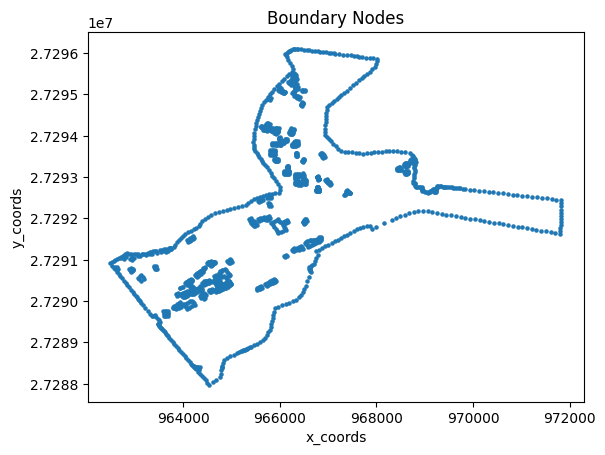

In [22]:
xx=pd.DataFrame(dd)
xx.plot.scatter(x="x_coords", y="y_coords", title="Boundary Nodes", marker='.')

In [23]:
print(chat.ask("can you list the materials in the model and their properties like a table?"))

httpx - INFO - HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
srh2d_qc.agent.chat_agent - INFO - Tool call: get_material_table({})
httpx - INFO - HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"


Here is the list of materials in the model along with their properties:

| ID | Material Name                      | Roughness |
|----|------------------------------------|-----------|
| 1  | Earthen Channel                    | 0.022     |
| 2  | Roadway/Parking Lot                | 0.020     |
| 3  | Vegetation - Medium                | 0.025     |
| 4  | Vegetation - Large                 | 0.050     |
| 5  | Railroad                            | 0.025     |
| 6  | Desert                              | 0.025     |
| 7  | Parks/Grass                        | 0.030     |
| 8  | Gravel                              | 0.035     |
| 9  | Firm Soil                          | 0.025     |
| 10 | Concrete                            | 0.015     |
| 11 | Vegetation - Small                 | 0.010     |
| 12 | Developed Medium Intensity         | 0.120     |

Let me know if you need further information!


In [9]:
print(chat.ask("how many boundary conditions are there in the model and what are their properties?"))

httpx - INFO - HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
srh2d_qc.agent.chat_agent - INFO - Tool call: get_all_model_class({"include_bcs": true})
srh2d_qc.agent.agent_tools - INFO - get_all_model_class requested: {'mesh': False, 'materials': False, 'bcs': True, 'run_config': False}
httpx - INFO - HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"


There are 16 boundary conditions (BCs) in the model. Here are their details:

1. **BC 1**: Type: MONITORING  
   Nodes: [9201, 9031, 8682, 8683, 8336, 8337, 7893, 2340, 2345, 2346]  
   Elements: [2129, 2130, 2133, 2134, 2135, 2137, 2138, 2139, 10502, 10503, 10504, 10505, 10511, 10512, 10513, 10514, 10515, 10516, 10540, 10542, 10547, 10548, 10549, 10551, 10658, 10659, 10670, 10671, 10674, 10677, 10713, 10714]

2. **BC 2**: Type: MONITORING  
   Nodes: [4182, 4278, 4377, 4378, 4458, 4459, 4526, 4585, 4586, 4628]  
   Elements: [5251, 5321, 5332, 5333, 5334, 5335, 5337, 5340, 5341, 5345, 5378, 5511, 5512, 5514, 5515, 5516, 5530, 5531, 5532, 5533, 5534, 5543, 5550, 5551, 5552, 5556]

3. **BC 3**: Type: MONITORING  
   Nodes: [19344, 18277, 18297, 18298, 18314, 18292, 18616, 18615, 18617, 18621]  
   Elements: [23480, 23481, 23483, 23484, 23489, 23492, 23494, 23496, 23497, 23498, 23500, 23536, 23537, 23770, 23771, 23773, 23774, 23776, 23778, 23780, 23785, 23786, 23787, 23789, 23818, 23839,

In [10]:
print(chat.ask("what is the nodes for element 152?"))

httpx - INFO - HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
srh2d_qc.agent.chat_agent - INFO - Tool call: get_element_nodes({"element_id": 152})
httpx - INFO - HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"


The nodes for element 152 are: 191, 192, 254, and 253.


In [11]:
print(chat.ask("create a qc report for this model"))

httpx - INFO - HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
srh2d_qc.agent.chat_agent - INFO - Tool call: run_qc({})
srh2d_qc.agent.chat_agent - INFO - Tool call: analyze_qc({})
srh2d_qc.agent.chat_agent - INFO - Tool call: propose_actions({})
srh2d_qc.agent.chat_agent - INFO - Tool call: get_qc_summary({})
httpx - INFO - HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"


Here is the QC report for the model:

### 1. Mesh Quality
- **Minimum Angle**: 16.40°
- **Maximum Angle**: 157.39°
- **Minimum Aspect Ratio**: 1.00
- **Maximum Aspect Ratio**: 4.98
- **Minimum Skewness**: 1.14e-07
- **Maximum Skewness**: 67.39
- **Minimum Area**: 1.57
- **Maximum Area**: 11019.77

### 2. Time Step Stability
- **dt**: 0.2
- **Minimum Geometric dt**: 0.52
- **Median Geometric dt**: 7.32
- **Number of Violations**: 0

### 3. Material Coverage
- **Missing Material IDs**: None
- **Unused Material IDs**: None

### 4. Boundary Condition Consistency
Numerous issues were identified across the boundary conditions:
- **BC 1**: Nodes not on boundary: [9201, 9031, 8682, 8683, 8336, 8337, 7893, 2340, 2345, 2346]
- **BC 2**: Nodes not on boundary: [4182, 4278, 4377, 4378, 4458, 4459, 4526, 4585, 4586, 4628]
- **BC 3**: Nodes not on boundary: [19344, 18277, 18297, 18298, 18314, 18292, 18616, 18615, 18617, 18621]
- **BC 4**: Nodes not on boundary: [15198, 14806, 14185, 10546, 10554, 10

In [12]:
print(chat.ask("can you create a table of the nodes in the mesh with their coordinates and save them locally?"))

httpx - INFO - HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
srh2d_qc.agent.chat_agent - INFO - Tool call: export_mesh_nodes_csv({})
srh2d_qc.agent.agent_tools - INFO - Exported mesh nodes to mesh_nodes.csv
httpx - INFO - HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"


I have created a table of the mesh nodes along with their coordinates and saved it as "mesh_nodes.csv" locally. It contains a total of 24,662 nodes.


In [13]:
chat.ask("plot the mesh (x vs y)")

httpx - INFO - HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
srh2d_qc.agent.chat_agent - INFO - Tool call: plot_mesh({"filename": "mesh.png", "title": "Mesh Nodes"})
srh2d_qc.agent.agent_tools - INFO - Saved mesh plot to mesh.png with 24662 nodes
httpx - INFO - HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"


'The mesh has been successfully plotted, and the image is saved as "mesh.png." It contains a total of 24,662 nodes. If you need anything else, feel free to ask!'

In [8]:
from srh2d_qc.agent.agent_core import SRH2D_QCAgent
from srh2d_qc.agent.chat_agent import SRH2DChatAgent
from srh2d_qc.llm.reasoner import LLMReasoner
agent = SRH2D_QCAgent(project_path, llm_reasoner=LLMReasoner())
agent.load()
agent.run_qc()

chat = SRH2DChatAgent(agent)
# print(chat.ask("create a table of materials in the model with their properties"))
print(chat.ask("can you list the materials in the model and their properties like a table?"))

Detected classic SRH-2D .srhgeom format in c:\dev\srh2d-qc-agent\tests\model_3\B3216_v4.srhgeom


httpx - INFO - HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
srh2d_qc.agent.chat_agent - INFO - Tool call: get_material_table({})
httpx - INFO - HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"


Here is a table of the materials in the model along with their properties:

| Material ID | Name                           | Roughness |
|-------------|--------------------------------|-----------|
| 1           | Earthen Channel                | 0.022     |
| 2           | Roadway/Parking Lot           | 0.020     |
| 3           | Vegetation - Medium            | 0.025     |
| 4           | Vegetation - Large             | 0.050     |
| 5           | Railroad                       | 0.025     |
| 6           | Desert                         | 0.025     |
| 7           | Parks/Grass                    | 0.030     |
| 8           | Gravel                         | 0.035     |
| 9           | Firm Soil                     | 0.025     |
| 10          | Concrete                       | 0.015     |
| 11          | Vegetation - Small             | 0.010     |
| 12          | Developed Medium Intensity     | 0.120     |

If you need more information, feel free to ask!


In [9]:
print(chat.ask("can you create a table of the nodes in the mesh with their coordinates? and make it as a file called test_download_data.csv?"))

httpx - INFO - HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
srh2d_qc.agent.chat_agent - INFO - Tool call: export_mesh_nodes_csv({"output_dir": "."})
srh2d_qc.agent.agent_tools - INFO - Exported mesh nodes to mesh_nodes.csv
httpx - INFO - HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"


The table of nodes in the mesh, along with their coordinates, has been successfully exported to a file named "mesh_nodes.csv". If you need any further assistance or additional exports, feel free to ask!


In [ ]:
print("\n--- Testing plotting tool ---")
print(chat.ask("Plot the mesh nodes (x coordinates vs y coordinates) and save it as a scatter plot."))


--- Testing different queries ---

1. Material query:


httpx - INFO - HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
srh2d_qc.agent.chat_agent - INFO - Tool call: get_material_table({})
httpx - INFO - HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"


The model has one material defined:

- **ID**: 1
- **Name**: default
- **Roughness**: 0.01

2. Mesh query:


httpx - INFO - HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
srh2d_qc.agent.chat_agent - INFO - Tool call: get_element_count({})
srh2d_qc.agent.chat_agent - INFO - Tool call: get_node_count({})
httpx - INFO - HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"


The mesh contains 6,000 elements and 6,321 nodes.
